#### import data

In [1]:
import pandas as pd
# import data
import kagglehub

# path = kagglehub.dataset_download("stealthtechnologies/employee-attrition-dataset")
# train_set = pd.read_csv(path+"/train.csv")
# test_set = pd.read_csv(path+"/test.csv")
train_set = pd.read_csv('data/train.csv')
test_set = pd.read_csv('data/test.csv')
dataset = pd.concat([train_set, test_set], axis=0, ignore_index=True)
dataset.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [2]:
dataset.drop(labels="Employee ID", axis=1, inplace=True)
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       74498 non-null  int64 
 1   Gender                    74498 non-null  object
 2   Years at Company          74498 non-null  int64 
 3   Job Role                  74498 non-null  object
 4   Monthly Income            74498 non-null  int64 
 5   Work-Life Balance         74498 non-null  object
 6   Job Satisfaction          74498 non-null  object
 7   Performance Rating        74498 non-null  object
 8   Number of Promotions      74498 non-null  int64 
 9   Overtime                  74498 non-null  object
 10  Distance from Home        74498 non-null  int64 
 11  Education Level           74498 non-null  object
 12  Marital Status            74498 non-null  object
 13  Number of Dependents      74498 non-null  int64 
 14  Job Level             

get unordinal and ordinal features

In [ ]:
ordinal_features = set(['Gender', 'Attrition', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Education Level', 'Job Level', 'Company Size', 'Company Reputation', 'Employee Recognition',])
unordinal_features = set(dataset.select_dtypes(include=['object']).columns) - ordinal_features

# print unique values of ordinal features
for feature in ordinal_features:
    print(f"{feature}: {dataset[feature].unique()}")

Performance Rating: ['Average' 'Low' 'High' 'Below Average']
Job Level: ['Mid' 'Senior' 'Entry']
Gender: ['Male' 'Female']
Work-Life Balance: ['Excellent' 'Poor' 'Good' 'Fair']
Company Reputation: ['Excellent' 'Fair' 'Poor' 'Good']
Job Satisfaction: ['Medium' 'High' 'Very High' 'Low']
Company Size: ['Medium' 'Small' 'Large']
Education Level: ['Associate Degree' 'Master’s Degree' 'Bachelor’s Degree' 'High School'
 'PhD']
Employee Recognition: ['Medium' 'Low' 'High' 'Very High']
Attrition: ['Stayed' 'Left']


In [ ]:
# ordinal features
dict_ordinal = {
    'Gender': {'Male': 0, 'Female': 1},
    'Employee Recognition': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
    'Company Size': {'Small': 0, 'Medium': 1, 'Large': 2},
    'Job Satisfaction': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
    'Performance Rating': {'Low': 0, 'Below Average': 1, 'Average': 2, 'High': 3},
    'Company Reputation': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
    'Education Level': {'High School': 0, 'Associate Degree': 1, 'Bachelor’s Degree': 2, 'Master’s Degree': 3, 'PhD': 4},
    'Job Level': {'Entry': 0, 'Mid': 1, 'Senior': 2},
    'Work-Life Balance': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
    'Attrition': {'Left': 0, 'Stayed': 1}
}
for feature in ordinal_features:
    dataset[feature] = dataset[feature].map(dict_ordinal[feature])

# unordinal features
for column in unordinal_features:
    dataset = dataset.join(pd.get_dummies(dataset[column], prefix=column))
    dataset.drop(labels=column, axis=1, inplace=True)

In [5]:
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           74498 non-null  int64
 1   Gender                        74498 non-null  int64
 2   Years at Company              74498 non-null  int64
 3   Monthly Income                74498 non-null  int64
 4   Work-Life Balance             74498 non-null  int64
 5   Job Satisfaction              74498 non-null  int64
 6   Performance Rating            74498 non-null  int64
 7   Number of Promotions          74498 non-null  int64
 8   Distance from Home            74498 non-null  int64
 9   Education Level               74498 non-null  int64
 10  Number of Dependents          74498 non-null  int64
 11  Job Level                     74498 non-null  int64
 12  Company Size                  74498 non-null  int64
 13  Company Tenure                7

1    0.525222
0    0.474778
Name: Attrition, dtype: float64


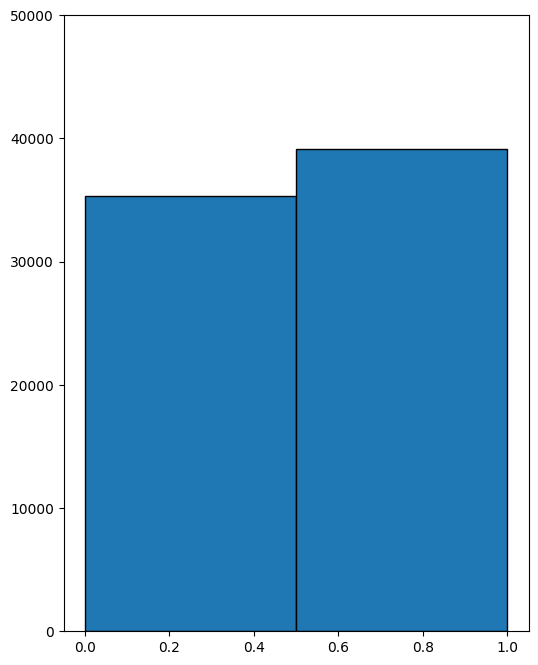

In [6]:
import matplotlib.pyplot as plt

print(dataset['Attrition'].value_counts() / dataset['Attrition'].count())
plt.figure(figsize=(6, 8))
plt.ylim(0, 50000)
plt.hist(dataset['Attrition'], bins=(2), edgecolor='black')
plt.show()

In [7]:
from sklearn.preprocessing  import StandardScaler, MinMaxScaler
sc = StandardScaler()
mc = MinMaxScaler()
# scale ordinal features
dataset[list(ordinal_features - {'Gender', 'Attrition'})] = mc.fit_transform(dataset[list(ordinal_features - {'Gender', 'Attrition'})])
# scale continous features
dataset[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']] = sc.fit_transform(dataset[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']])
dataset.to_csv('processed.csv', index=False)

In [8]:
print(dataset["Attrition"])

0        1
1        1
2        1
3        1
4        1
        ..
74493    1
74494    0
74495    0
74496    1
74497    0
Name: Attrition, Length: 74498, dtype: int64
